Андреев Иван М8О-310Б-22

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

train_data.head()


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


## Подготовка данных

Чтобы подготовить данные, необходимо выполнить следующие шаги:

1. **Парсинг даты:**
   - Распарсить дату и преобразовать её в числовой формат.
   - Удалить столбец с датой после преобразования.

2. **Кодирование категориальных данных:**
   - Применить one-hot encoding для категориальных переменных, чтобы подготовить их для анализа.

In [161]:
# Преобразуем ApplicationDate в числовые значения
train_data['ApplicationDate'] = pd.to_datetime(train_data['ApplicationDate'])
train_data['ApplicationYear'] = train_data['ApplicationDate'].dt.year
train_data['ApplicationMonth'] = train_data['ApplicationDate'].dt.month
train_data['ApplicationDay'] = train_data['ApplicationDate'].dt.day

test_data['ApplicationDate'] = pd.to_datetime(test_data['ApplicationDate'])
test_data['ApplicationYear'] = test_data['ApplicationDate'].dt.year
test_data['ApplicationMonth'] = test_data['ApplicationDate'].dt.month
test_data['ApplicationDay'] = test_data['ApplicationDate'].dt.day

# Удаляем оригинальный столбец даты
train_data.drop(columns=['ApplicationDate'], inplace=True)

test_data.drop(columns=['ApplicationDate'], inplace=True)

# Применяем one-hot encoding для категориальных переменных
train_data = pd.get_dummies(train_data, columns=['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel'], drop_first=True)

test_data = pd.get_dummies(test_data, columns=['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel'], drop_first=True)

Убедимся в корректности преобразований данных.

In [162]:
train_data.head()


,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master
0,27.0,66829.0,549.0,17290.0,60.0,1.0,1095.0,0.151985,2.0,1.0,...,False,True,False,False,False,False,False,False,False,False
1,55.0,172147.0,850.0,16110.0,36.0,1.0,211.0,0.175693,3.0,0.0,...,False,False,True,False,False,False,False,False,True,False
2,51.0,300000.0,850.0,38436.0,36.0,0.0,546.0,0.444605,3.0,0.0,...,False,True,False,False,False,False,True,False,False,False
3,25.0,34683.0,847.0,19186.0,48.0,0.0,153.0,0.188452,7.0,0.0,...,True,False,False,False,False,False,False,False,True,False
4,55.0,300000.0,850.0,30437.0,48.0,2.0,562.0,0.273431,3.0,1.0,...,True,False,False,False,False,False,True,False,False,False


## Дубликаты и пропуски

Удалим дубликаты.

In [163]:
train_data = train_data.drop_duplicates(keep='first')

Посмотрим, сколько пропусков у нас есть и какую долю от общего объема данных они составляют.

In [164]:
total_rows = train_data.shape[0]

missing_values = train_data.isnull().sum()

missing_percentage = (missing_values / total_rows) * 100

missing_values[missing_values > 0]
missing_percentage[missing_percentage > 0]

Age                           0.009999
AnnualIncome                  0.009999
CreditScore                   4.719528
LoanAmount                    4.719528
LoanDuration                  0.009999
NumberOfDependents            0.009999
MonthlyDebtPayments           4.719528
CreditCardUtilizationRate     0.009999
NumberOfOpenCreditLines       0.009999
NumberOfCreditInquiries       0.009999
DebtToIncomeRatio             0.009999
BankruptcyHistory             4.719528
PreviousLoanDefaults          0.009999
PaymentHistory                0.009999
LengthOfCreditHistory         0.009999
SavingsAccountBalance         0.009999
CheckingAccountBalance        4.719528
TotalAssets                   4.719528
TotalLiabilities              0.009999
MonthlyIncome                 0.009999
UtilityBillsPaymentHistory    0.009999
JobTenure                     0.009999
Experience                    0.009999
NetWorth                      4.719528
BaseInterestRate              4.719528
InterestRate             

Процент пропусков в большинстве столбцов составляет менее 5%, что является незначительной долей от общего объема, поэтому строки с пропусками можно просто удалить.

In [165]:
train_data = train_data.dropna()
train_data.isnull().sum()

Age                               0
AnnualIncome                      0
CreditScore                       0
LoanAmount                        0
LoanDuration                      0
NumberOfDependents                0
MonthlyDebtPayments               0
CreditCardUtilizationRate         0
NumberOfOpenCreditLines           0
NumberOfCreditInquiries           0
DebtToIncomeRatio                 0
BankruptcyHistory                 0
PreviousLoanDefaults              0
PaymentHistory                    0
LengthOfCreditHistory             0
SavingsAccountBalance             0
CheckingAccountBalance            0
TotalAssets                       0
TotalLiabilities                  0
MonthlyIncome                     0
UtilityBillsPaymentHistory        0
JobTenure                         0
Experience                        0
NetWorth                          0
BaseInterestRate                  0
InterestRate                      0
MonthlyLoanPayment                0
TotalDebtToIncomeRatio      

## Обработка корреляций

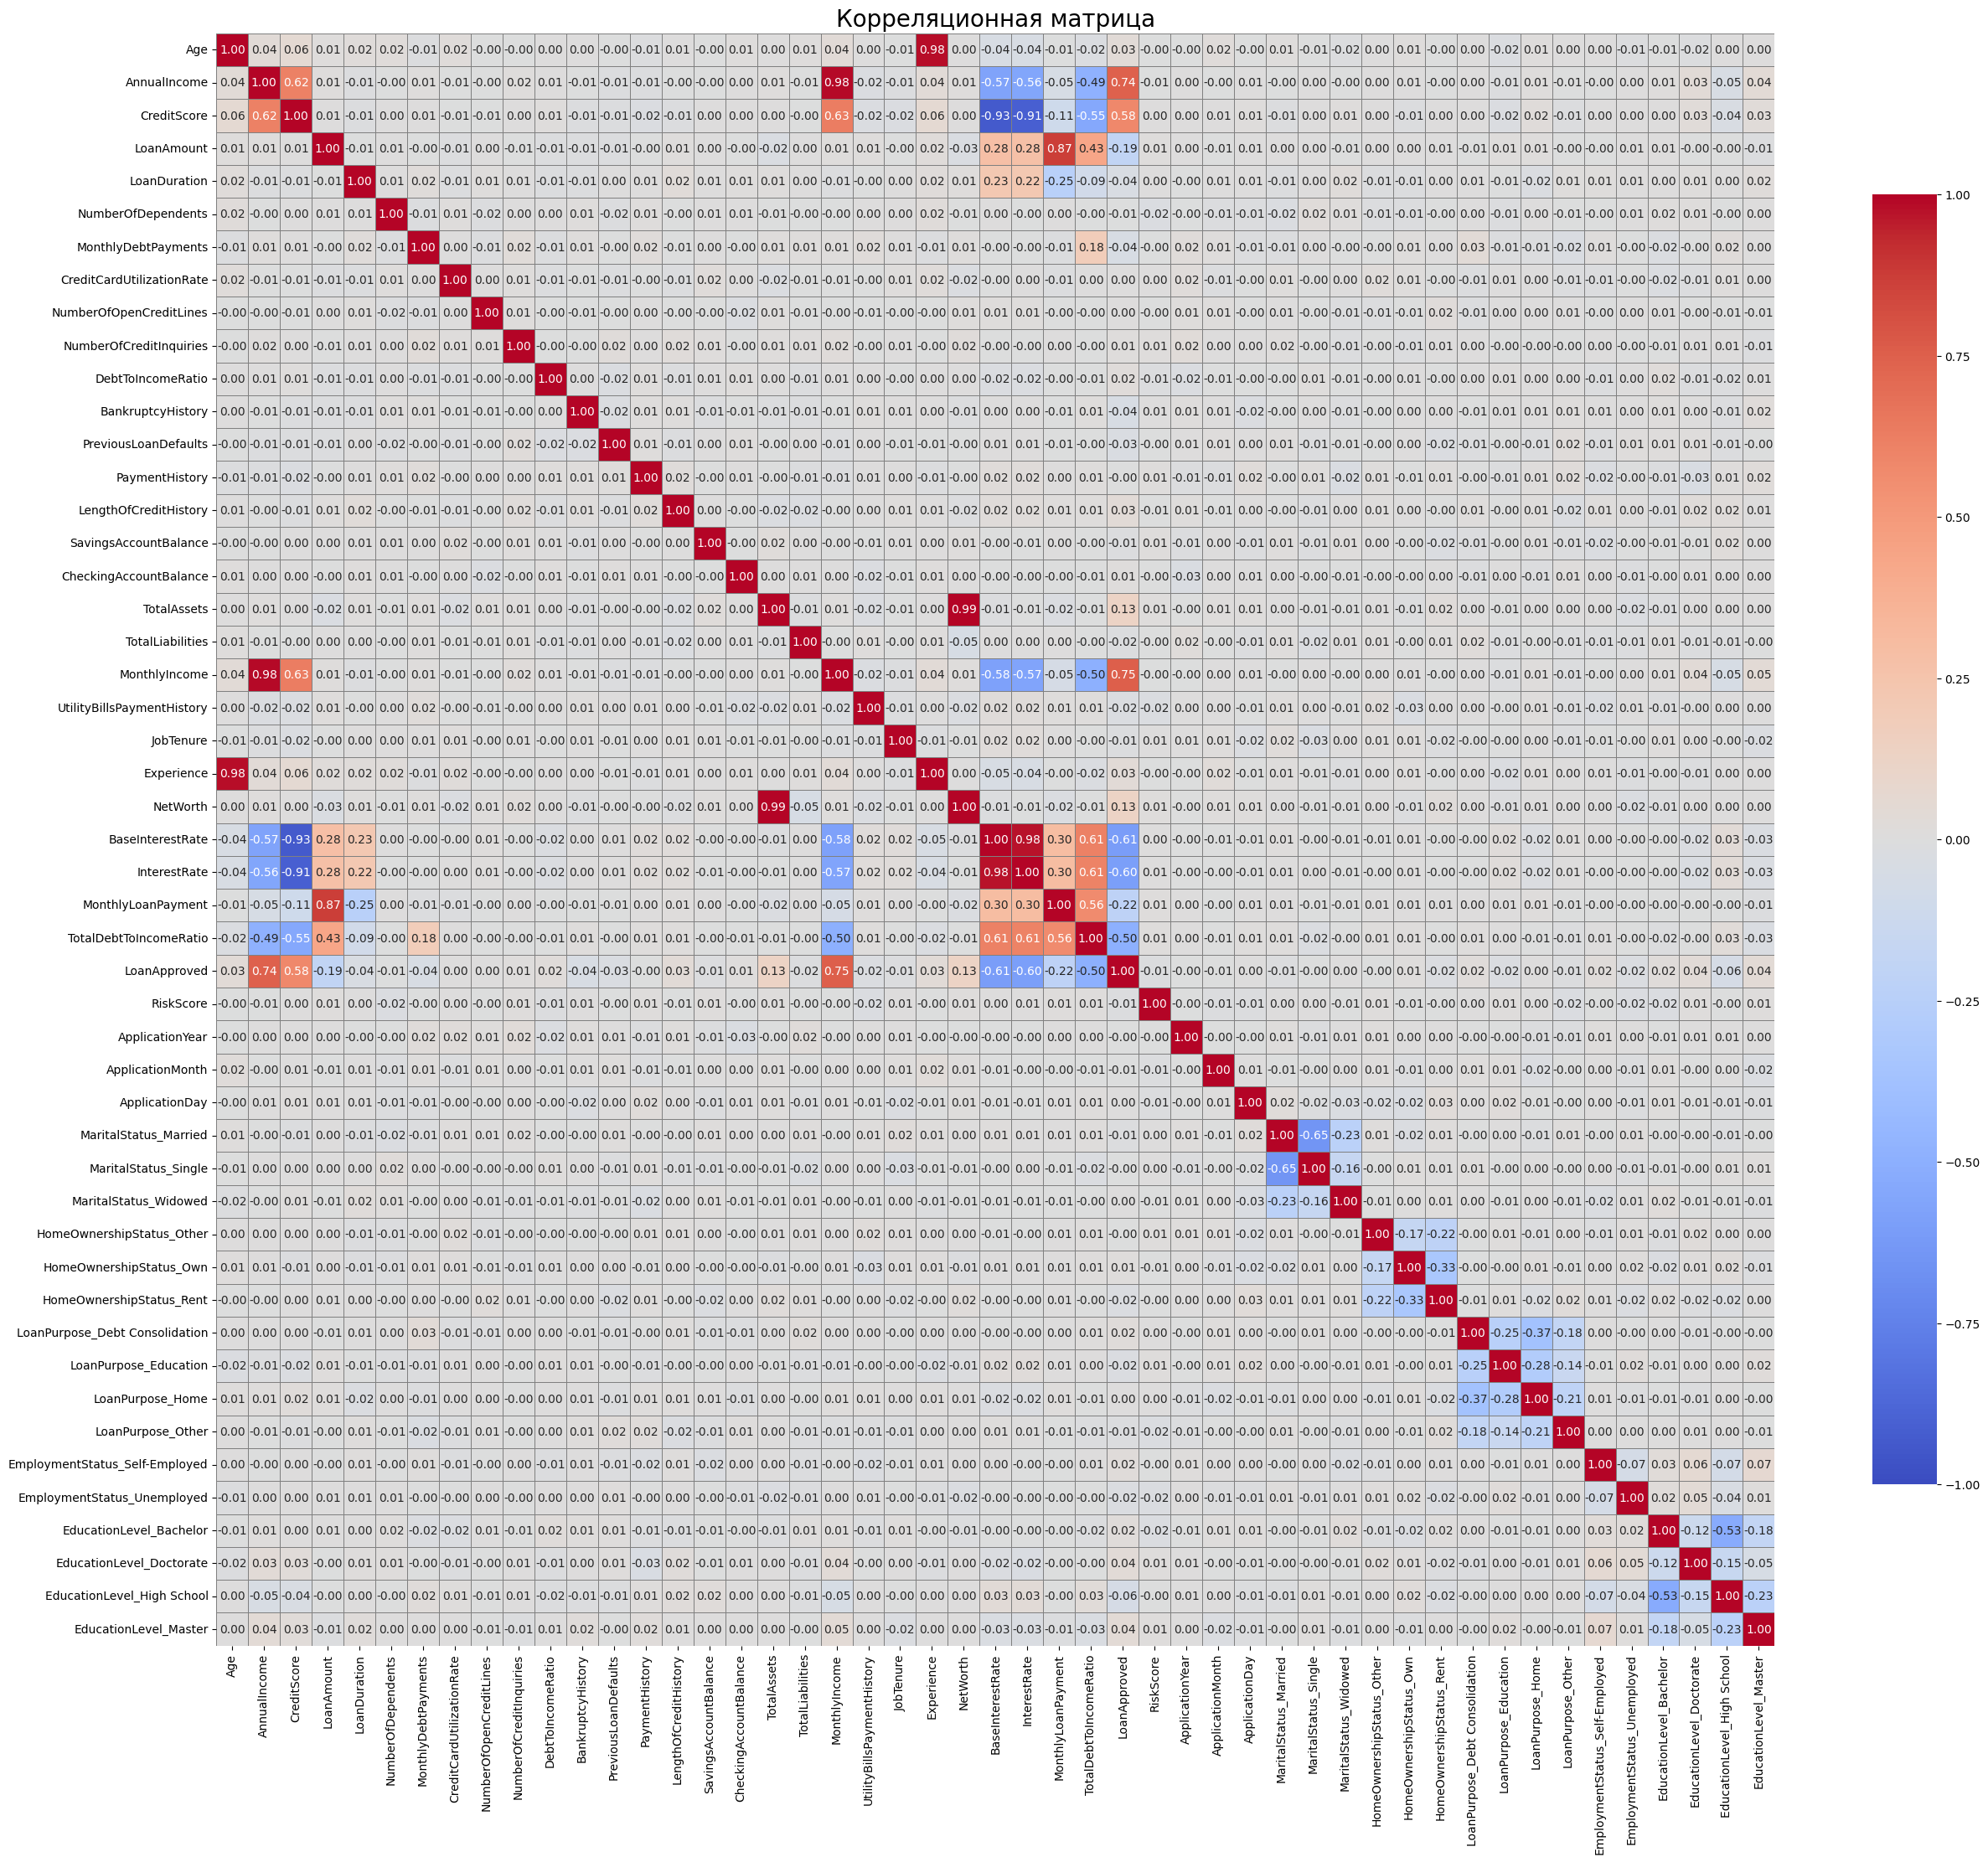

In [166]:
corr_matrix = train_data.corr()

plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix, 
             annot=True, 
             fmt=".2f", 
             annot_kws={"size": 10}, 
             cmap="coolwarm", 
             vmin=-1, 
             vmax=1, 
             linewidths=0.5, 
             linecolor='gray', 
             cbar_kws={"shrink": .8}
            )
plt.title("Корреляционная матрица", fontsize=20)
plt.show()

In [167]:
# Порог корреляции
threshold = 0.8

# Получаем список переменных для удаления
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >= threshold:  
            colname = corr_matrix.columns[i]  
            to_drop.add(colname)  

# Сохраняем исходные названия колонок для сравнения
original_columns = train_data.columns.tolist()

# Удаляем избыточные переменные из обучающего и тестового наборов
train_data = train_data.drop(columns=to_drop)
test_data = test_data.drop(columns=to_drop)

# Выводим информацию о том, какие переменные были удалены
removed_columns = [col for col in original_columns if col in to_drop]
print("Удаленные переменные:", removed_columns)

Удаленные переменные: ['MonthlyIncome', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment']


## Нормализация признаков

In [168]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

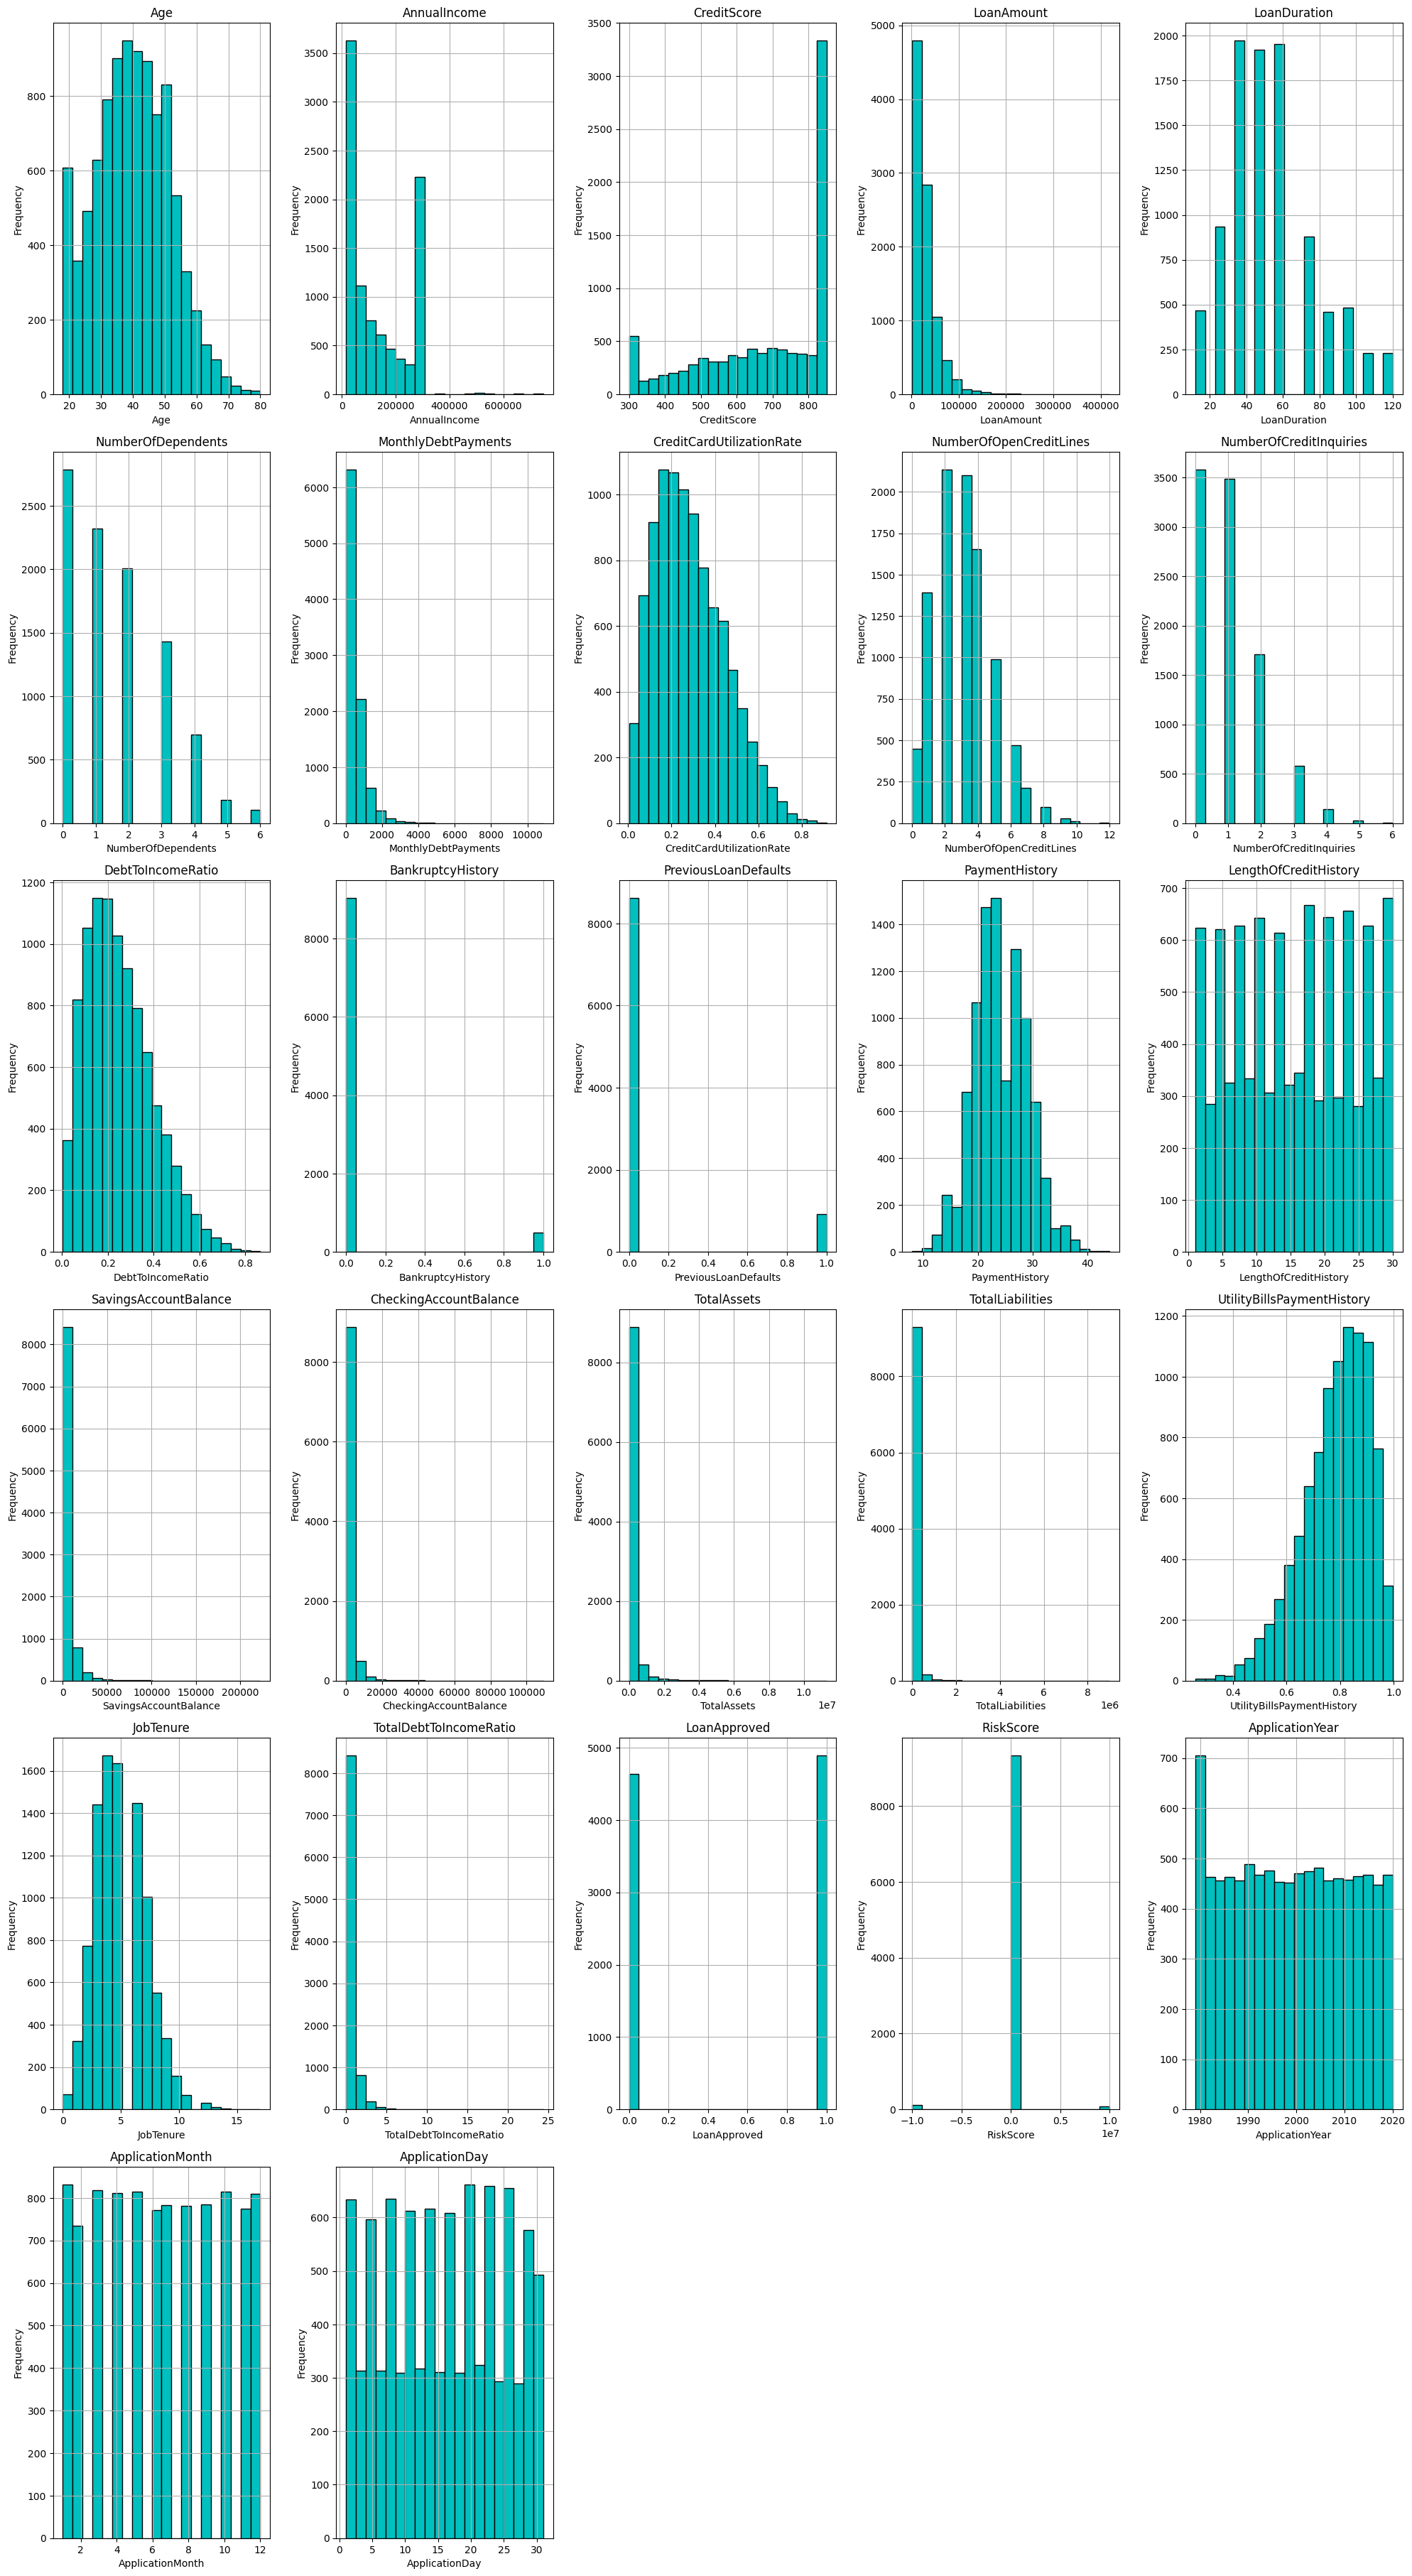

In [169]:

# Устанавливаем количество строк и столбцов для подграфиков
nrows = 8
ncols = 5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 6 * nrows))

# Перебираем столбцы в данных
for idx, column in enumerate(train_data.select_dtypes(include='number').columns):
    ax = axes[idx // ncols, idx % ncols]  # Получаем текущий подграфик
    train_data[column].hist(ax=ax, bins=20, color='c', edgecolor='black')
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

# Удаляем лишние подграфики, если столбцов меньше, чем подграфиков
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j // ncols, j % ncols])

plt.tight_layout()
plt.show()

In [170]:
scalerMinMax = MinMaxScaler()
scalerStandard = StandardScaler()

def scale(train_data):

    standard = ['Age', 'LoanDuration', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'DebtToIncomeRatio', 
                'PaymentHistory', 'UtilityBillsPaymentHistory', 'JobTenure']
    
    minmax = ['CreditScore', 'LengthOfCreditHistory', 'year', 'month', 'day']

    log = ['LoanAmount', 'MonthlyDebtPayments', 'NumberOfCreditInquiries', 'SavingsAccountBalance', 
           'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'TotalDebtToIncomeRatio', 'NumberOfDependents']
    
    train_data[standard] = scalerStandard.fit_transform(train_data[standard])
    train_data[minmax] = scalerMinMax.fit_transform(train_data[minmax])
    train_data[log] = np.log1p(train_data[log])
    train_data[log] = scalerStandard.fit_transform(train_data[log])

    return train_data

## Обучение модели

In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Параметры для GridSearch
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [1000, 5000, 10000, 50000]
}

# Убираем значения, выходящие за пределы [−100, 50]
train_data = train_data[(train_data['RiskScore'] >= -100) & (train_data['RiskScore'] <= 50)]

# Разделяем данные на признаки и целевую переменную
X = train_data.drop('RiskScore', axis=1)
Y = train_data['RiskScore']

# Инициализируем модель
ridge = Ridge()

# Настройка модели с помощью GridSearchCV
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X, Y)

# Выводим лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)

# Обучаем модель с лучшими параметрами
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X)

# Вычисляем среднеквадратичную ошибку
print("MSE: ", mean_squared_error(Y, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'alpha': 1, 'max_iter': 1000}
MSE:  11.486585595592253


In [172]:
ids = test_data['ID']
test_data = test_data.drop('ID', axis=1)

predictions = best_model.predict(test_data)

result = pd.DataFrame({
    'ID': ids,
    'RiskScore': predictions
})

result.to_csv('submission.csv', index=False)